# Meeting Context, Couple Type, and Relationship Stability

This analysis asks two related questions: first, whether same-sex and different-sex couples differ in how they meet; second, whether meeting context predicts later relationship outcomes, controlling for prior survival and demographic characteristics.


## 1. Research Goal

This analysis has two goals:

1. Compare same-sex and different-sex couples in how they meet.
2. Test whether meeting context predicts later relationship status.

The core comparison is descriptive first, then adjusted. The descriptive sections show how meeting pathways differ by couple type and how stability varies across meeting-profile clusters. The model section asks whether those patterns remain after accounting for baseline controls and earlier relationship survival.


## 2. Build Meeting-Context Features

The survey contains detailed indicators for where or how respondents met their partner. To make the analysis interpretable, those detailed indicators are collapsed into three broader meeting-context features:

- `met_social`: friends, family, neighbors, public places, parties, restaurants, or vacation.
- `met_work`: coworkers, customers, work neighbors, or business trips.
- `met_online`: dating sites/apps, social networks, other internet settings, or the general online meeting indicator.

These categories are not mutually exclusive. A couple can have more than one pathway marked if the detailed survey responses point to multiple contexts.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

import statsmodels.formula.api as smf

plt.style.use("default")
pd.set_option("display.max_columns", 100)

DATA_PATH = "../../data/HCMST 2017 to 2022 small public version 2.2.dta"
df = pd.read_stata(DATA_PATH).copy()

print(f"Rows retained from original wide panel file: {len(df):,}")


/tmp/ipykernel_28957/312435002.py:16: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  df = pd.read_stata(DATA_PATH).copy()


Rows retained from original wide panel file: 3,510


In [3]:
social_cols = [
    "w1_q24_met_through_friend",
    "w1_q24_met_through_family",
    "w1_q24_met_through_as_nghbrs",
    "w1_q24_bar_restaurant",
    "w1_q24_party",
    "w1_q24_public",
    "w1_q24_vacation",
]

work_cols = [
    "w1_q24_met_as_through_cowork",
    "w1_q24_customer",
    "w1_q24_work_neighbors",
    "w1_q24_business_trip",
]

online_cols = [
    "w1_q24_internet_dating",
    "w1_q24_internet_soc_network",
    "w1_q24_internet_other",
    "w1_q24_met_online",
]

all_meeting_cols = social_cols + work_cols + online_cols

binary_map = {
    "yes": 1,
    "no": 0,
    "1": 1,
    "1.0": 1,
    "0": 0,
    "0.0": 0,
}

for col in all_meeting_cols:
    df[col] = (
        df[col]
        .astype("string")
        .str.strip()
        .str.lower()
        .map(binary_map)
    )

df["met_social"] = (df[social_cols].sum(axis=1) > 0).astype(int)
df["met_work"] = (df[work_cols].sum(axis=1) > 0).astype(int)
df["met_online"] = (df[online_cols].sum(axis=1) > 0).astype(int)

meeting_feature_summary = df[["met_social", "met_work", "met_online"]].mean().mul(100).round(2)
display(meeting_feature_summary.rename("Share of Wave 1 couples (%)"))


met_social    53.48
met_work      22.42
met_online    11.45
Name: Share of Wave 1 couples (%), dtype: float64

model results depend on feature construction

In [4]:
df["w1_ppage"] = pd.to_numeric(df["w1_ppage"], errors="coerce")
df["w1_age_when_met"] = pd.to_numeric(df["w1_age_when_met"], errors="coerce")
df["relationship_duration"] = df["w1_ppage"] - df["w1_age_when_met"]

df["w1_same_sex_couple"] = (
    df["w1_same_sex_couple"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map({
        "same_sex_couple": 1,
        "not same-sex souple": 0,
        "not same-sex couple": 0,
    })
)

df["couple_type"] = df["w1_same_sex_couple"].map({
    0: "Different-sex couples",
    1: "Same-sex couples",
})

display(df["couple_type"].value_counts(dropna=False).rename("Unweighted count"))


couple_type
Different-sex couples    3086
Same-sex couples          308
NaN                       116
Name: Unweighted count, dtype: int64

## 3. Cluster Relationship Profiles

The clustering step groups couples into relationship profiles using age/timing and broad meeting context. The selected variables are:

- `w1_age_when_met`
- `relationship_duration`
- `met_social`
- `met_work`
- `met_online`

K-means is fit on standardized variables so that age and duration do not dominate the binary meeting-context indicators.


In [5]:
cluster_features = [
    "w1_age_when_met",
    "relationship_duration",
    "met_social",
    "met_work",
    "met_online",
]

df_cluster = df[cluster_features].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
df_cluster["cluster"] = kmeans.fit_predict(X_scaled)

print(f"Rows used for clustering: {len(df_cluster):,}")
display(df_cluster[cluster_features].describe().round(2))


Rows used for clustering: 3,341


,w1_age_when_met,relationship_duration,met_social,met_work,met_online
count,3341.00,3341.00,3341.00,3341.00,3341.00
mean,26.65,22.77,0.56,0.23,0.12
std,11.83,17.11,0.50,0.42,0.32
min,0.00,0.00,0.00,0.00,0.00
25%,18.00,8.00,0.00,0.00,0.00
50%,23.00,19.00,1.00,0.00,0.00
75%,32.00,36.00,1.00,0.00,0.00
max,84.00,78.00,1.00,1.00,1.00


In [6]:
cluster_profile = df_cluster.groupby("cluster")[cluster_features].mean().round(3)
cluster_sizes = df_cluster["cluster"].value_counts().sort_index().rename("n")
interpretation_table = cluster_profile.join(cluster_sizes)

display(interpretation_table)


,w1_age_when_met,relationship_duration,met_social,met_work,met_online,n
cluster,,,,,,
0,24.576000,25.433,0.663,0.000,0.000,2170
1,34.028000,6.624,0.411,0.013,0.997,399
2,28.672001,23.633,0.332,1.000,0.000,772


In [7]:
# Assign final names from the dominant meeting-context feature in each cluster.
meeting_cols = ["met_social", "met_work", "met_online"]
name_by_feature = {
    "met_social": "Socially-initiated relationships",
    "met_work": "Work-based relationships",
    "met_online": "Online-initiated relationships",
}

cluster_names = {
    cluster_id: name_by_feature[row[meeting_cols].idxmax()]
    for cluster_id, row in cluster_profile.iterrows()
}

mapping_table = (
    pd.Series(cluster_names, name="cluster_name")
    .rename_axis("cluster")
    .reset_index()
)

df_cluster["cluster_name"] = df_cluster["cluster"].map(cluster_names)
df["cluster"] = np.nan
df.loc[df_cluster.index, "cluster"] = df_cluster["cluster"]
df["cluster_name"] = df["cluster"].map(cluster_names)

display(mapping_table)
display(
    df_cluster.groupby("cluster_name")[cluster_features]
    .mean()
    .round(3)
    .loc[["Work-based relationships", "Socially-initiated relationships", "Online-initiated relationships"]]
)


,cluster,cluster_name
0,0,Socially-initiated relationships
1,1,Online-initiated relationships
2,2,Work-based relationships


,w1_age_when_met,relationship_duration,met_social,met_work,met_online
cluster_name,,,,,
Work-based relationships,28.672001,23.633,0.332,1.000,0.000
Socially-initiated relationships,24.576000,25.433,0.663,0.000,0.000
Online-initiated relationships,34.028000,6.624,0.411,0.013,0.997


#### Note 

Based on the distribution of reported meeting contexts, many respondents selected multiple options.

0 yes      758

1 yes    1,371

2 yes      932

3 yes      303

4 yes       27

5 yes        3

missing   116

 This indicates that the data does not strictly capture a single “first meeting” pathway, but rather the different contexts involved in how couples met.

As a result, the clusters should be interpreted as dominant patterns of reported meeting contexts, rather than mutually exclusive or strictly sequential meeting categories.

The final mapping is based on the dominant meeting-context feature in each cluster. This keeps the interpretation tied to the observed cluster profile rather than the arbitrary numeric label returned by K-means.


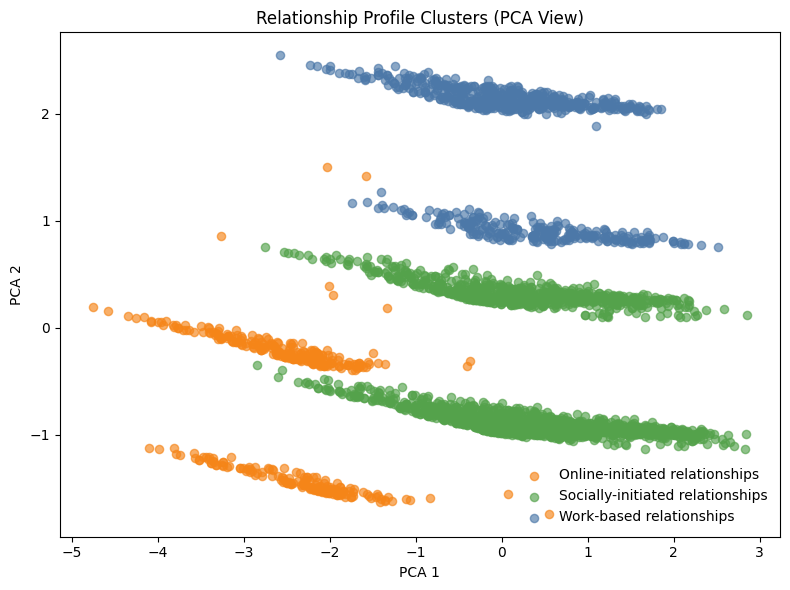

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster_name": df_cluster["cluster_name"].values,
})

colors = {
    "Work-based relationships": "#4C78A8",
    "Socially-initiated relationships": "#54A24B",
    "Online-initiated relationships": "#F58518",
}

plt.figure(figsize=(8, 6))
for name, group in plot_df.groupby("cluster_name"):
    plt.scatter(group["PC1"], group["PC2"], label=name, alpha=0.65, s=35, color=colors.get(name))

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Relationship Profile Clusters (PCA View)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [18]:
df.groupby("w1_same_sex_couple")[["met_social","met_work","met_online"]].mean() * 100

,met_social,met_work,met_online
w1_same_sex_couple,,,
0.0,55.573558,23.979261,9.948153
1.0,52.597403,15.259740,30.844156


## 4. Descriptive Comparison by Couple Type

This is the central descriptive comparison: **weighted** meeting pathways by couple type. The bars show the weighted share of different-sex and same-sex couples who report each broad meeting context. Because the meeting-context features are not mutually exclusive, the three bars for a couple type do not need to sum to 100%.


,met_social,met_work,met_online
couple_type,,,
Different-sex couples,54.60,23.44,9.61
Same-sex couples,50.35,15.60,30.22


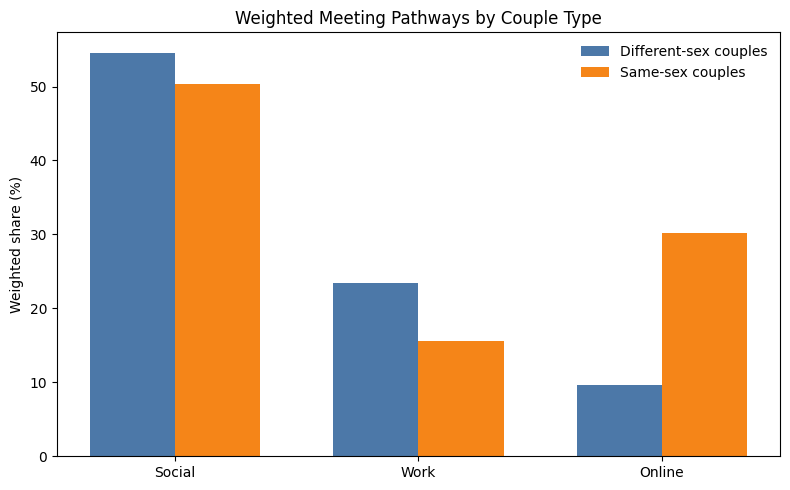

In [9]:
def weighted_means(frame, group_col, value_cols, weight_col):
    rows = []
    for group_value, group in frame.dropna(subset=[group_col, weight_col]).groupby(group_col, observed=False):
        row = {group_col: group_value}
        for col in value_cols:
            temp = group[[col, weight_col]].dropna()
            row[col] = np.average(temp[col], weights=temp[weight_col]) if len(temp) else np.nan
        rows.append(row)
    return pd.DataFrame(rows).set_index(group_col)

meeting_cols = ["met_social", "met_work", "met_online"]
meeting_labels = ["Social", "Work", "Online"]

weighted_meeting_by_couple = (
    weighted_means(df, "couple_type", meeting_cols, "w1_weight_combo")
    .loc[["Different-sex couples", "Same-sex couples"]]
    .mul(100)
    .round(2)
)

display(weighted_meeting_by_couple)

x = np.arange(len(meeting_labels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(
    x - width / 2,
    weighted_meeting_by_couple.loc["Different-sex couples", meeting_cols],
    width,
    label="Different-sex couples",
    color="#4C78A8",
)
plt.bar(
    x + width / 2,
    weighted_meeting_by_couple.loc["Same-sex couples", meeting_cols],
    width,
    label="Same-sex couples",
    color="#F58518",
)
plt.xticks(x, meeting_labels)
plt.ylabel("Weighted share (%)")
plt.title("Weighted Meeting Pathways by Couple Type")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


Same-sex couples are much more likely to report meeting online than different-sex couples. Social pathways remain common for both groups, while work-based meeting is lower among same-sex couples.


## 5. Relationship Stability by Cluster

Wave 2 is the main descriptive outcome because it is closer to the baseline survey and less affected by later panel attrition. Wave 3 is included as a limited follow-up view, but it should be interpreted more carefully because it depends on continued panel retention and response.


In [10]:
df["still_together_w2"] = df["w2_breakup_year"].isna().astype(int)
df["still_together_w3"] = df["w3_breakup_source"].isna().astype(int)

stability_by_cluster = pd.DataFrame({
    "Wave 2 still together %": df.groupby("cluster_name", observed=False)["still_together_w2"].mean().mul(100),
    "Wave 2 n": df.groupby("cluster_name", observed=False)["still_together_w2"].count(),
    "Wave 3 still together %": df.groupby("cluster_name", observed=False)["still_together_w3"].mean().mul(100),
    "Wave 3 n": df.groupby("cluster_name", observed=False)["still_together_w3"].count(),
}).round(2)

stability_by_cluster = stability_by_cluster.loc[
    ["Work-based relationships", "Socially-initiated relationships", "Online-initiated relationships"]
]

display(stability_by_cluster)


,Wave 2 still together %,Wave 2 n,Wave 3 still together %,Wave 3 n
cluster_name,,,,
Work-based relationships,95.21,772,97.67,772
Socially-initiated relationships,94.93,2170,96.87,2170
Online-initiated relationships,89.22,399,94.49,399


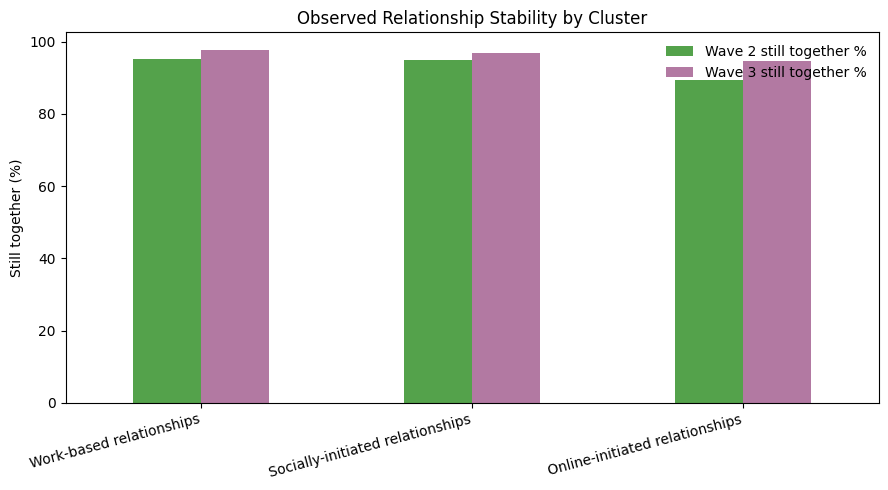

In [11]:
plot_stability = stability_by_cluster[["Wave 2 still together %", "Wave 3 still together %"]]

ax = plot_stability.plot(
    kind="bar",
    figsize=(9, 5),
    color=["#54A24B", "#B279A2"],
)
ax.set_ylabel("Still together (%)")
ax.set_xlabel("")
ax.set_title("Observed Relationship Stability by Cluster")
ax.legend(frameon=False)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


The Wave 2 comparison is the stronger descriptive read. Wave 3 points in the same broad direction, but it is a more limited follow-up because fewer cases remain observable in the later panel wave.


## 6. Adjusted Model

The adjusted analysis keeps the two-model comparison:

- Model A predicts Wave 3 relationship survival using baseline relationship profile and controls.
- Model B adds Wave 2 survival, testing whether meeting context still predicts later status after accounting for earlier observed stability.

The interpretation focuses on Work vs Online, Wave 2 survival, marriage, and whether same-sex couple status is statistically significant.


In [12]:
model_df = df[[
    "still_together_w3",
    "still_together_w2",
    "cluster_name",
    "w1_married",
    "w1_same_sex_couple",
    "w1_partner_yrsed",
]].copy()

model_df["w1_married_num"] = (
    model_df["w1_married"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map({"yes": 1, "no": 0})
    .astype("float")
)
model_df["w1_partner_yrsed"] = pd.to_numeric(model_df["w1_partner_yrsed"], errors="coerce")

cluster_ref = "Online-initiated relationships"

model_a_df = model_df.dropna(subset=[
    "still_together_w3",
    "cluster_name",
    "w1_married_num",
    "w1_same_sex_couple",
    "w1_partner_yrsed",
]).copy()

logit_a = smf.logit(
    f"still_together_w3 ~ C(cluster_name, Treatment(reference='{cluster_ref}')) + "
    "w1_married_num + w1_same_sex_couple + w1_partner_yrsed",
    data=model_a_df,
).fit(disp=False)

model_b_df = model_df.dropna(subset=[
    "still_together_w3",
    "still_together_w2",
    "cluster_name",
    "w1_married_num",
    "w1_same_sex_couple",
    "w1_partner_yrsed",
]).copy()

logit_b = smf.logit(
    f"still_together_w3 ~ C(cluster_name, Treatment(reference='{cluster_ref}')) + "
    "still_together_w2 + w1_married_num + w1_same_sex_couple + w1_partner_yrsed",
    data=model_b_df,
).fit(disp=False)


def odds_ratio_table(model):
    return pd.DataFrame({
        "odds_ratio": np.exp(model.params),
        "ci_lower": np.exp(model.conf_int()[0]),
        "ci_upper": np.exp(model.conf_int()[1]),
        "p_value": model.pvalues,
    }).round(3)

or_table_a = odds_ratio_table(logit_a)
or_table_b = odds_ratio_table(logit_b)

sample_table = pd.DataFrame({
    "model": ["Model A: baseline controls", "Model B: + Wave 2 survival"],
    "n_used": [len(model_a_df), len(model_b_df)],
})

display(sample_table)
print("Model A odds ratios")
display(or_table_a)
print("Model B odds ratios")
display(or_table_b)


,model,n_used
0,Model A: baseline controls,3333
1,Model B: + Wave 2 survival,3333


Model A odds ratios


,odds_ratio,ci_lower,ci_upper,p_value
Intercept,33.383,9.931,112.219,0.000
"C(cluster_name, Treatment(reference='Online-initiated relationships'))[T.Socially-initiated relationships]",1.518,0.907,2.539,0.112
"C(cluster_name, Treatment(reference='Online-initiated relationships'))[T.Work-based relationships]",1.999,1.039,3.845,0.038
w1_married_num,2.012,1.335,3.034,0.001
w1_same_sex_couple,1.321,0.681,2.561,0.410
w1_partner_yrsed,0.938,0.867,1.014,0.108


Model B odds ratios


,odds_ratio,ci_lower,ci_upper,p_value
Intercept,10.658,2.999,37.880,0.000
"C(cluster_name, Treatment(reference='Online-initiated relationships'))[T.Socially-initiated relationships]",1.406,0.832,2.377,0.203
"C(cluster_name, Treatment(reference='Online-initiated relationships'))[T.Work-based relationships]",1.844,0.948,3.586,0.071
still_together_w2,4.769,2.901,7.838,0.000
w1_married_num,1.630,1.064,2.497,0.025
w1_same_sex_couple,1.381,0.706,2.701,0.346
w1_partner_yrsed,0.934,0.863,1.011,0.093


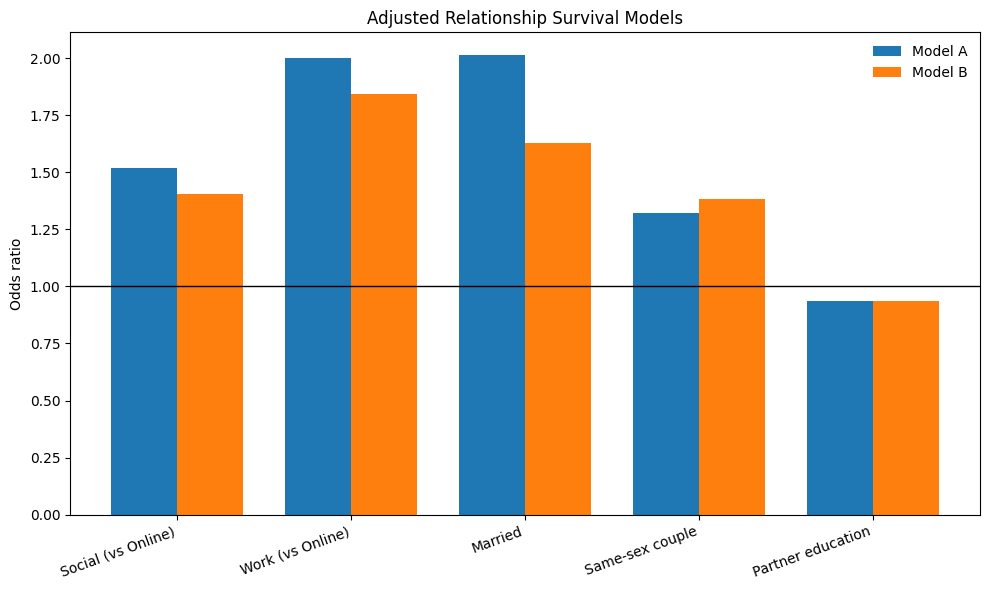

In [13]:
rename_dict = {
    "C(cluster_name, Treatment(reference='Online-initiated relationships'))[T.Socially-initiated relationships]": "Social (vs Online)",
    "C(cluster_name, Treatment(reference='Online-initiated relationships'))[T.Work-based relationships]": "Work (vs Online)",
    "still_together_w2": "Survived Wave 2",
    "w1_married_num": "Married",
    "w1_same_sex_couple": "Same-sex couple",
    "w1_partner_yrsed": "Partner education",
}

plot_a = or_table_a.rename(index=rename_dict).drop(index="Intercept")
plot_b = or_table_b.rename(index=rename_dict).drop(index="Intercept")
common_vars = plot_a.index.intersection(plot_b.index)

x = np.arange(len(common_vars))
width = 0.38

plt.figure(figsize=(10, 6))
plt.bar(x - width / 2, plot_a.loc[common_vars, "odds_ratio"], width, label="Model A")
plt.bar(x + width / 2, plot_b.loc[common_vars, "odds_ratio"], width, label="Model B")
plt.axhline(1, color="black", linewidth=1)
plt.xticks(x, common_vars, rotation=20, ha="right")
plt.ylabel("Odds ratio")
plt.title("Adjusted Relationship Survival Models")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


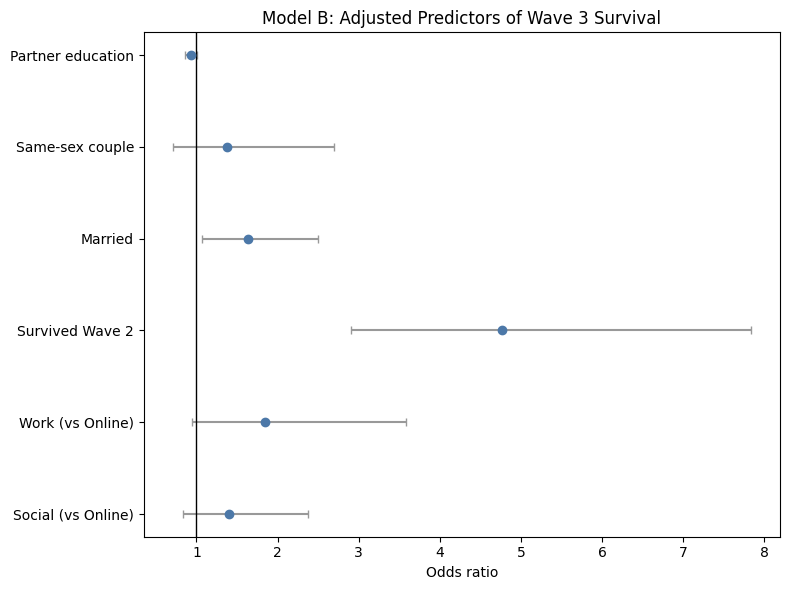

In [14]:
model_b_plot = or_table_b.rename(index=rename_dict).drop(index="Intercept")

plt.figure(figsize=(8, 6))
y_pos = np.arange(len(model_b_plot))
plt.errorbar(
    model_b_plot["odds_ratio"],
    y_pos,
    xerr=[
        model_b_plot["odds_ratio"] - model_b_plot["ci_lower"],
        model_b_plot["ci_upper"] - model_b_plot["odds_ratio"],
    ],
    fmt="o",
    color="#4C78A8",
    ecolor="#999999",
    capsize=3,
)
plt.yticks(y_pos, model_b_plot.index)
plt.axvline(1, color="black", linewidth=1)
plt.xlabel("Odds ratio")
plt.title("Model B: Adjusted Predictors of Wave 3 Survival")
plt.tight_layout()
plt.show()


In [15]:
pred_b = logit_b.predict(model_b_df)
pred_b_class = (pred_b > 0.5).astype(int)

print("Model B accuracy:", round(accuracy_score(model_b_df["still_together_w3"], pred_b_class), 3))
print("Model B ROC AUC:", round(roc_auc_score(model_b_df["still_together_w3"], pred_b), 3))
print("Observed Wave 3 survival rate in Model B sample:", round(model_b_df["still_together_w3"].mean(), 3))


Model B accuracy: 0.968
Model B ROC AUC: 0.673
Observed Wave 3 survival rate in Model B sample: 0.968


Interpretation focus:

- Work-based relationships have higher odds of Wave 3 survival than online-initiated relationships in the adjusted comparison.
- Wave 2 survival is the strongest predictor in Model B, as expected: relationships still together at Wave 2 are much more likely to be observed as still together at Wave 3.
- Marriage is positively associated with survival.
- Same-sex couple status is not statistically significant after adjustment, so the model does not show evidence that same-sex couples differ in later survival net of meeting context and controls.
- The model should not be treated as highly predictive. Breakup is rare in the analytic sample, so accuracy can look high even when ROC AUC is modest.


### Testing Adding Age as control 

In [20]:
model_df = df[[
    "still_together_w3",
    "still_together_w2",
    "cluster_name",
    "w1_married",
    "w1_same_sex_couple",
    "w1_partner_yrsed",
    "w1_age_when_met",   # 👈 ADDED
]].copy()

# Clean married
model_df["w1_married_num"] = (
    model_df["w1_married"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map({"yes": 1, "no": 0})
    .astype("float")
)

# Clean numeric columns
model_df["w1_partner_yrsed"] = pd.to_numeric(model_df["w1_partner_yrsed"], errors="coerce")
model_df["w1_age_when_met"] = pd.to_numeric(model_df["w1_age_when_met"], errors="coerce")  # 👈 ADDED

cluster_ref = "Online-initiated relationships"

# -----------------------------
# Model A
# -----------------------------
model_a_df = model_df.dropna(subset=[
    "still_together_w3",
    "cluster_name",
    "w1_married_num",
    "w1_same_sex_couple",
    "w1_partner_yrsed",
    "w1_age_when_met",   # 👈 ADDED
]).copy()

logit_a = smf.logit(
    f"still_together_w3 ~ C(cluster_name, Treatment(reference='{cluster_ref}')) + "
    "w1_married_num + w1_same_sex_couple + w1_partner_yrsed + w1_age_when_met",  # 👈 ADDED
    data=model_a_df,
).fit(disp=False)

# -----------------------------
# Model B
# -----------------------------
model_b_df = model_df.dropna(subset=[
    "still_together_w3",
    "still_together_w2",
    "cluster_name",
    "w1_married_num",
    "w1_same_sex_couple",
    "w1_partner_yrsed",
    "w1_age_when_met",   # 👈 ADDED
]).copy()

logit_b = smf.logit(
    f"still_together_w3 ~ C(cluster_name, Treatment(reference='{cluster_ref}')) + "
    "still_together_w2 + w1_married_num + w1_same_sex_couple + w1_partner_yrsed + w1_age_when_met",  # 👈 ADDED
    data=model_b_df,
).fit(disp=False)

def odds_ratio_table(model):
    return pd.DataFrame({
        "odds_ratio": np.exp(model.params),
        "ci_lower": np.exp(model.conf_int()[0]),
        "ci_upper": np.exp(model.conf_int()[1]),
        "p_value": model.pvalues,
    }).round(3)

or_table_a = odds_ratio_table(logit_a)
or_table_b = odds_ratio_table(logit_b)

sample_table = pd.DataFrame({
    "model": ["Model A: baseline controls", "Model B: + Wave 2 survival"],
    "n_used": [len(model_a_df), len(model_b_df)],
})

display(sample_table)
print("Model A odds ratios")
display(or_table_a)
print("Model B odds ratios")
display(or_table_b)

,model,n_used
0,Model A: baseline controls,3333
1,Model B: + Wave 2 survival,3333


Model A odds ratios


,odds_ratio,ci_lower,ci_upper,p_value
Intercept,59.708,15.925,223.868,0.000
"C(cluster_name, Treatment(reference='Online-initiated relationships'))[T.Socially-initiated relationships]",1.319,0.778,2.236,0.304
"C(cluster_name, Treatment(reference='Online-initiated relationships'))[T.Work-based relationships]",1.868,0.968,3.605,0.062
w1_married_num,1.803,1.180,2.754,0.006
w1_same_sex_couple,1.343,0.695,2.598,0.380
w1_partner_yrsed,0.943,0.872,1.020,0.141
w1_age_when_met,0.983,0.968,0.997,0.021


Model B odds ratios


,odds_ratio,ci_lower,ci_upper,p_value
Intercept,18.392,4.601,73.521,0.000
"C(cluster_name, Treatment(reference='Online-initiated relationships'))[T.Socially-initiated relationships]",1.235,0.719,2.121,0.445
"C(cluster_name, Treatment(reference='Online-initiated relationships'))[T.Work-based relationships]",1.722,0.882,3.363,0.112
still_together_w2,4.628,2.810,7.622,0.000
w1_married_num,1.482,0.955,2.299,0.079
w1_same_sex_couple,1.402,0.718,2.737,0.322
w1_partner_yrsed,0.939,0.867,1.017,0.121
w1_age_when_met,0.984,0.969,1.000,0.044


“The effect of meeting context weakens after controlling for prior relationship status and age, suggesting that differences in outcomes are partly explained by underlying relationship characteristics.”

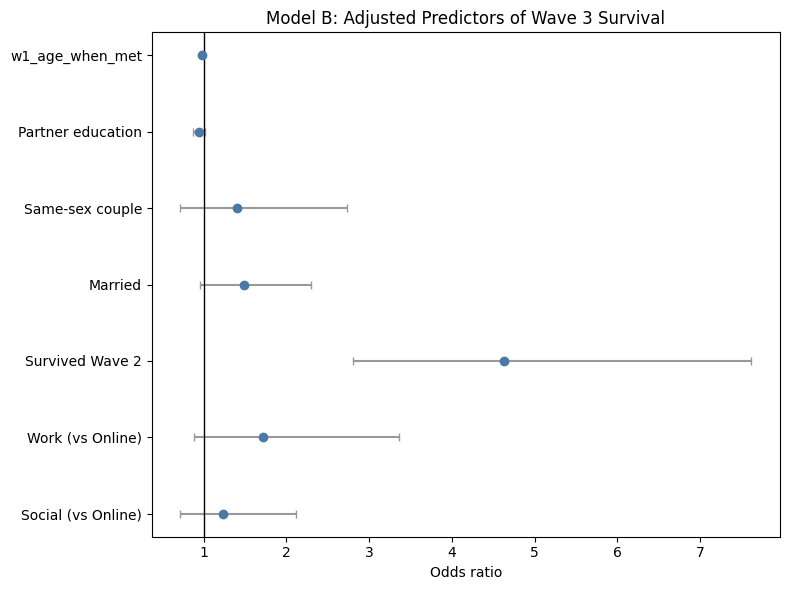

In [21]:
model_b_plot = or_table_b.rename(index=rename_dict).drop(index="Intercept")

plt.figure(figsize=(8, 6))
y_pos = np.arange(len(model_b_plot))
plt.errorbar(
    model_b_plot["odds_ratio"],
    y_pos,
    xerr=[
        model_b_plot["odds_ratio"] - model_b_plot["ci_lower"],
        model_b_plot["ci_upper"] - model_b_plot["odds_ratio"],
    ],
    fmt="o",
    color="#4C78A8",
    ecolor="#999999",
    capsize=3,
)
plt.yticks(y_pos, model_b_plot.index)
plt.axvline(1, color="black", linewidth=1)
plt.xlabel("Odds ratio")
plt.title("Model B: Adjusted Predictors of Wave 3 Survival")
plt.tight_layout()
plt.show()


## 7. Weighted Descriptive Robustness Check

This section is descriptive only and is kept separate from the adjusted model. It checks whether the main composition and stability patterns remain visible when applying survey weights.


In [16]:
def weighted_distribution(frame, group_col, weight_col):
    temp = frame[[group_col, weight_col]].dropna().copy()
    out = temp.groupby(group_col, observed=False)[weight_col].sum()
    return out / out.sum()


def weighted_mean_by_group(frame, group_col, value_col, weight_col):
    rows = []
    for group_value, group in frame[[group_col, value_col, weight_col]].dropna().groupby(group_col, observed=False):
        rows.append({
            group_col: group_value,
            value_col: np.average(group[value_col], weights=group[weight_col]),
        })
    return pd.DataFrame(rows).set_index(group_col)[value_col]

composition_compare = pd.DataFrame({
    "Unweighted sample %": (df["couple_type"].value_counts(normalize=True) * 100).round(2),
    "Weighted population %": (weighted_distribution(df, "couple_type", "w1_weight_combo") * 100).round(2),
}).loc[["Different-sex couples", "Same-sex couples"]]

weighted_cluster_summary = pd.concat([
    weighted_distribution(df, "cluster_name", "w1_weight_combo").mul(100).round(2).rename("Weighted Wave 1 share %"),
    weighted_mean_by_group(df, "cluster_name", "still_together_w2", "w2_combo_weight").mul(100).round(2).rename("Weighted Wave 2 still together %"),
    weighted_mean_by_group(df, "cluster_name", "still_together_w3", "w3_combo_weight").mul(100).round(2).rename("Weighted Wave 3 still together %"),
], axis=1).loc[["Work-based relationships", "Socially-initiated relationships", "Online-initiated relationships"]]

display(composition_compare)
display(weighted_cluster_summary)


,Unweighted sample %,Weighted population %
couple_type,,
Different-sex couples,90.93,97.459999
Same-sex couples,9.07,2.540000


,Weighted Wave 1 share %,Weighted Wave 2 still together %,Weighted Wave 3 still together %
cluster_name,,,
Work-based relationships,23.230000,91.85,95.80
Socially-initiated relationships,66.580002,89.04,93.08
Online-initiated relationships,10.200000,83.84,86.38


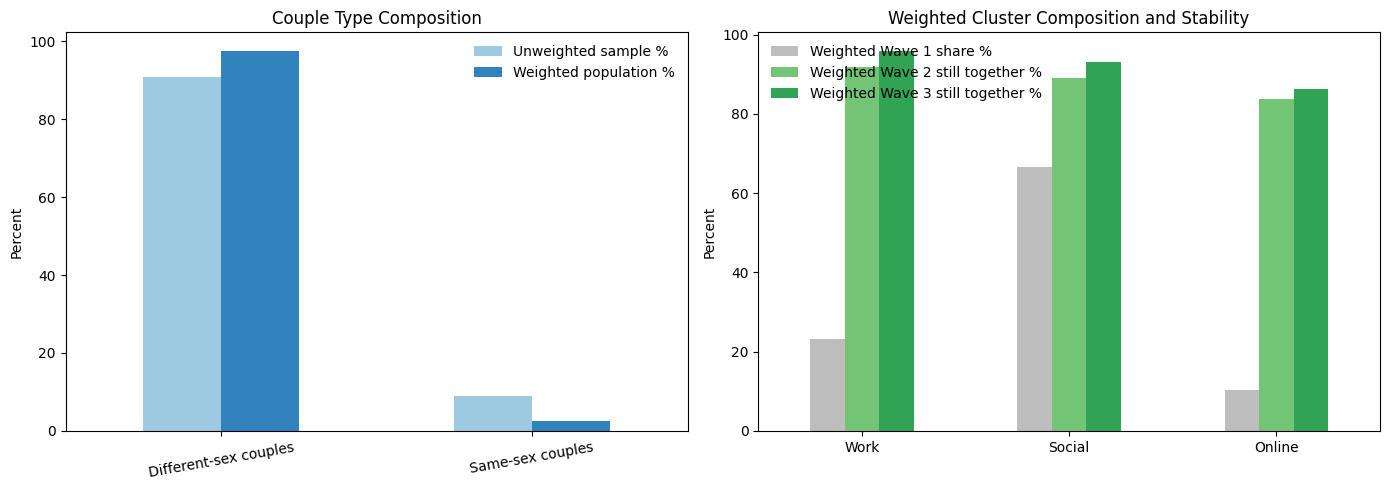

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

composition_compare.plot(
    kind="bar",
    ax=axes[0],
    color=["#9ecae1", "#3182bd"],
)
axes[0].set_ylabel("Percent")
axes[0].set_xlabel("")
axes[0].set_title("Couple Type Composition")
axes[0].legend(frameon=False)
axes[0].tick_params(axis="x", rotation=10)

weighted_cluster_summary.plot(
    kind="bar",
    ax=axes[1],
    color=["#bdbdbd", "#74c476", "#31a354"],
)
axes[1].set_ylabel("Percent")
axes[1].set_xlabel("")
axes[1].set_title("Weighted Cluster Composition and Stability")
axes[1].set_xticklabels(["Work", "Social", "Online"], rotation=0)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()


The weighted descriptive check supports the main story: same-sex couples remain disproportionately likely to report online meeting pathways, and online-initiated relationships show lower observed stability than work-based relationships. These are descriptive weighted comparisons, not adjusted causal estimates.


## 8. Limitations

- The same original panel rows are retained in wide format. Rows are not expanded into person-wave records, so later-wave variables are analyzed as columns on the original respondent row.
- Later waves are filtered by panel retention and response. A Wave 2 or Wave 3 outcome is only observable for respondents who remain in the panel and provide the relevant follow-up information.
- Wave 3 is especially less reliable as a descriptive outcome because it is farther from baseline and more affected by attrition and missingness.
- Breakup is a rare outcome in the analytic sample, so the adjusted model has modest predictive power even when some coefficients are substantively meaningful.
- The meeting-context categories are broad and not mutually exclusive. They simplify interpretation but cannot fully capture the complexity of how couples met.


## 9. Final Conclusion

Same-sex and different-sex couples differ most clearly in online meeting: same-sex couples are much more likely to meet online. Meeting context also relates to later relationship status, with work-based relationships appearing more stable than online-initiated relationships. After adjustment, same-sex couple status itself is not a significant predictor of later survival; the stronger signals are meeting context, marriage, and especially whether the relationship had already survived to Wave 2.
